## Bias-Variance Illustration


Suppose we have fit a model $\widehat{f}(x)$ to some training data $\{{X}_i,{Y}_i\}_{i=1}^n$. Let $(x_0, y_0)$ be a test observation from the population. The true model is $Y=f(X)+\varepsilon$ (where $f(x)=\mathbb{E}[Y|X=x]$). Then the MSE of the test data is:
\begin{align*}
\mathbb{E}[(y_0-\widehat{f}(x_0))^2] = \mathrm{Var}(\varepsilon) + [\mathrm{Bias}(\widehat{f}(x_0))]^2 + \mathrm{Var}(\widehat{f}(x_0))
\end{align*}
where $\mathrm{Bias}(\widehat{f}(x_0)) = \mathbb{E}[\widehat{f}(x_0)] - f(x_0)$.

The expectation $\mathbb{E}$ averages over the variability of $y_0$ as well as variability in the training data.

Below we compare different models to predict $Y$ from $X$ where the true relationship is nonlinear. 

- Left: Plot of true function, draw of training data, fit to the training data
- Middle: Plot of fitted functions for different training datasets (to give a visual of variance of $\widehat{f}$)
- Right: Plot of average of fitted functions and true function (to give a visual of bias of $\mathbb{E}[\widehat{f}(x)]$)

### Linear regression fit to nonlinear data

![](fig/bias-variance-simple.gif)

### Piecewise polynomial fit to nonlinear data (with regularization)

![](fig/bias-variance-regularized.gif)

### Piecewise polynomial fit to nonlinear data (no regularization)

![](fig/bias-variance-complex.gif)

## Poisson Regression

*Adapted from Introduction to Statistical Learning with Python* [(link)](https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch04-classification-lab.ipynb)

We consider the Bike Share data from class.

In [15]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

In [16]:
Bike = load_data('Bikeshare')

In [17]:
Bike.shape, Bike.columns

((8645, 15),
 Index(['season', 'mnth', 'day', 'hr', 'holiday', 'weekday', 'workingday',
        'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
        'registered', 'bikers'],
       dtype='object'))

In [18]:
features = ['mnth', 'hr', 'workingday', 'temp', 'weathersit']

In [19]:
Bike['workingday'].value_counts()

workingday
1    5911
0    2734
Name: count, dtype: int64

In [20]:
Bike['weathersit'].value_counts()

weathersit
clear              5645
cloudy/misty       2218
light rain/snow     781
heavy rain/snow       1
Name: count, dtype: int64

In [21]:
X = MS(['mnth',
        'hr',
        'workingday',
        'temp',
        'weathersit']).fit_transform(Bike)
Y = Bike['bikers']

In [22]:
X.columns

Index(['intercept', 'mnth[Feb]', 'mnth[March]', 'mnth[April]', 'mnth[May]',
       'mnth[June]', 'mnth[July]', 'mnth[Aug]', 'mnth[Sept]', 'mnth[Oct]',
       'mnth[Nov]', 'mnth[Dec]', 'hr[1]', 'hr[2]', 'hr[3]', 'hr[4]', 'hr[5]',
       'hr[6]', 'hr[7]', 'hr[8]', 'hr[9]', 'hr[10]', 'hr[11]', 'hr[12]',
       'hr[13]', 'hr[14]', 'hr[15]', 'hr[16]', 'hr[17]', 'hr[18]', 'hr[19]',
       'hr[20]', 'hr[21]', 'hr[22]', 'hr[23]', 'workingday', 'temp',
       'weathersit[cloudy/misty]', 'weathersit[heavy rain/snow]',
       'weathersit[light rain/snow]'],
      dtype='object')

In [23]:
M_pois = sm.GLM(Y, X, family=sm.families.Poisson()).fit()

In [24]:
M_pois.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 bikers   No. Observations:                 8645
Model:                            GLM   Df Residuals:                     8605
Model Family:                 Poisson   Df Model:                           39
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4054e+05
Date:                Mon, 23 Feb 2026   Deviance:                   2.2804e+05
Time:                        13:27:35   Pearson chi2:                 2.20e+05
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
intercept                       2.6937      0.010    277.124      0.000       2.675       2.713
mnth[Feb]                       0.2260      0.007     32.521      0.000       0.212       0.240
mnth[March]                     0.3764      0.007     56.263      0.000       0.363       0.390
mnth[April]                     0.6917      0.007     98.996      0.000       0.678       0.705
mnth[May]                       0.9106      0.007    122.469      0.000       0.896       0.925
mnth[June]                      0.8934      0.008    108.402      0.000       0.877       0.910
mnth[July]                      0.7738      0.009     87.874      0.000       0.757       0.791
mnth[Aug]                       0.8213      0.008     98.573      0.000       0.805       0.838
mnth[Sept]                      0.9037      0.008    118.578      0.000       0.889       0.919
mnth[Oct]                       0.9377      0.007    139.054      0.000       0.925       0.951
mnth[Nov]                       0.8204      0.006    126.334      0.000       0.808       0.833
mnth[Dec]                       0.6868      0.006    108.724      0.000       0.674       0.699
hr[1]                          -0.4716      0.013    -36.278      0.000      -0.497      -0.446
hr[2]                          -0.8088      0.015    -55.220      0.000      -0.837      -0.780
hr[3]                          -1.4439      0.019    -76.631      0.000      -1.481      -1.407
hr[4]                          -2.0761      0.025    -83.728      0.000      -2.125      -2.027
hr[5]                          -1.0603      0.016    -65.957      0.000      -1.092      -1.029
hr[6]                           0.3245      0.011     30.585      0.000       0.304       0.345
hr[7]                           1.3296      0.009    146.822      0.000       1.312       1.347
hr[8]                           1.8313      0.009    211.630      0.000       1.814       1.848
hr[9]                           1.3362      0.009    148.191      0.000       1.318       1.354
hr[10]                          1.0912      0.009    117.831      0.000       1.073       1.109
hr[11]                          1.2485      0.009    137.304      0.000       1.231       1.266
hr[12]                          1.4340      0.009    160.486      0.000       1.417       1.452
hr[13]                          1.4280      0.009    159.529      0.000       1.410       1.445
hr[14]                          1.3793      0.009    153.266      0.000       1.362       1.397
hr[15]                          1.4081      0.009    156.862      0.000       1.391       1.426
hr[16]                          1.6287      0.009    184.979      0.000       1.611       1.646
hr[17]                          2.0490      0.009    239.221      0.000       2.032       2.066
hr[18]     

In [25]:
S_pois = summarize(M_pois)

coef_month = S_pois[S_pois.index.str.contains('mnth')]['coef']
coef_month = pd.concat([pd.Series([0],
                                   index=['mnth[Jan]']), coef_month])
coef_hr = S_pois[S_pois.index.str.contains('hr')]['coef']
coef_hr = pd.concat([pd.Series([0],
                     index=['hr[0]']), coef_hr])

In [26]:
coef_month

mnth[Jan]      0.0000
mnth[Feb]      0.2260
mnth[March]    0.3764
mnth[April]    0.6917
mnth[May]      0.9106
mnth[June]     0.8934
mnth[July]     0.7738
mnth[Aug]      0.8213
mnth[Sept]     0.9037
mnth[Oct]      0.9377
mnth[Nov]      0.8204
mnth[Dec]      0.6868
dtype: float64

In [27]:
x_month = np.arange(coef_month.shape[0])
x_hr = np.arange(coef_hr.shape[0])

/var/folders/f0/m7l23y8s7p3_0x04b3td9nyjr2hyc8/T/ipykernel_28453/3779510511.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_hr.set_xticklabels(range(24)[::2], fontsize=20)


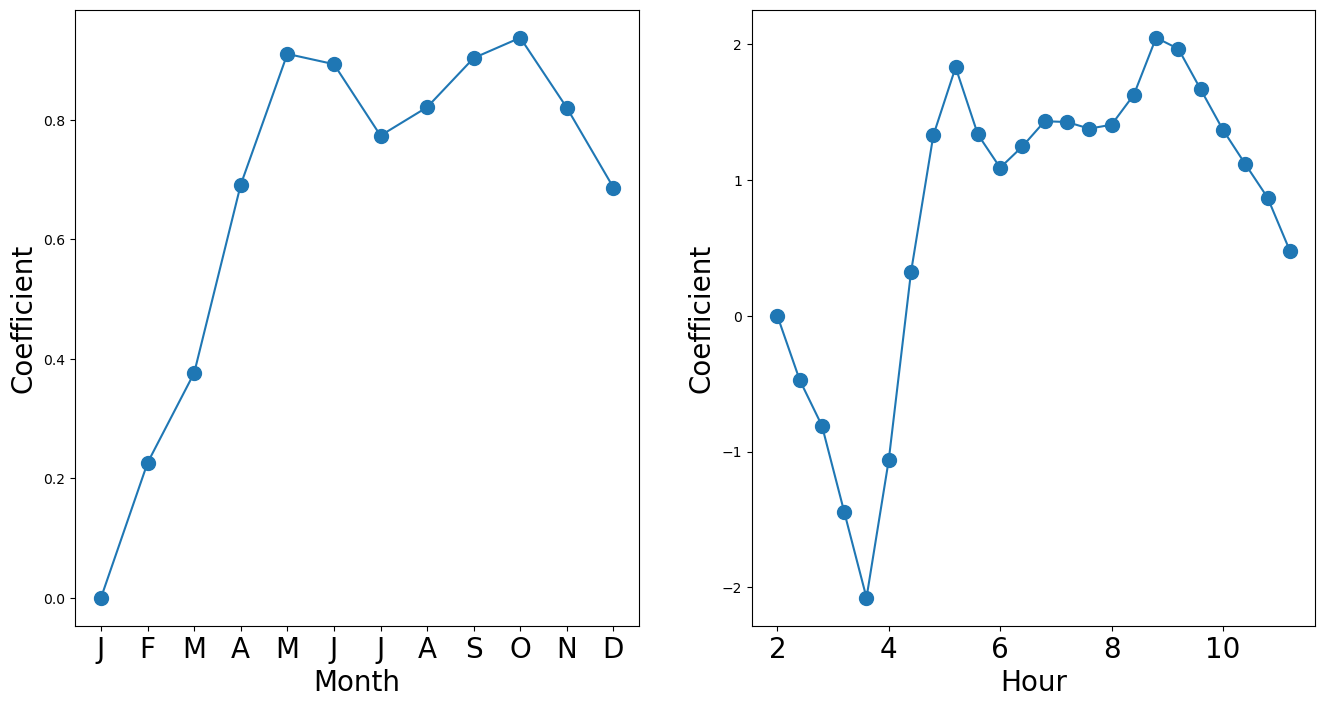

In [28]:
fig_pois, (ax_month, ax_hr) = subplots(1, 2, figsize=(16,8))
ax_month.plot(x_month, coef_month, marker='o', ms=10)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels([l[5] for l in coef_month.index], fontsize=20)
ax_month.set_xlabel('Month', fontsize=20)
ax_month.set_ylabel('Coefficient', fontsize=20)
ax_hr.plot(x_hr, coef_hr, marker='o', ms=10)
ax_hr.set_xticklabels(range(24)[::2], fontsize=20)
ax_hr.set_xlabel('Hour', fontsize=20)
ax_hr.set_ylabel('Coefficient', fontsize=20);